## Averadge the data inside 1° grid

In [1]:
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

#### Import Data

In [181]:
all_data = pd.read_csv("Final MP stock concentrations.csv", sep = ';')
all_data

,Author,Lat,Lon,Shape,year of sampling,MP mass observation extrapolated to 1-5000 µm (µg/kg) from MPsizeBase,MP stock (g/m2) in year of study Martin,MP stock (g/m2) in year of study Restreppo,MP stock (g/m2) in 2021
0,Wang et al..,33.0000,122.2100,Fibers,2017,28.4,0.002853,0.001496,0.001780
1,Wang et al..,34.0000,121.2400,Fibers,2017,"1,11E+02",0.002949,0.013206,0.015716
2,Wang et al..,36.0000,121.0000,Fibers,2017,"1,80E+02",0.003179,0.006921,0.008236
3,Wang et al..,33.0000,123.0000,Fibers,2017,74.8,0.002410,0.004677,0.005565
4,Wang et al..,35.0000,121.3900,Fibers,2017,81.9,0.004460,0.002211,0.002631
...,...,...,...,...,...,...,...,...,...
326,Goswami et al..,11.0026,75.1158,Fibers,2017,0.672668791454022,0.000021,0.000019,0.000023
327,Goswami et al..,11.9959,74.4228,Fibers,2017,0.364080114605785,0.000010,0.000009,0.000011
328,Goswami et al..,12.9984,73.8962,Fibers,2017,0.425815438386767,0.000012,0.000011,0.000013
329,Goswami et al..,14.0007,73.3301,Fibers,2017,0.240697409100492,0.000007,0.000006,0.000007


In [182]:
all_data_fib = all_data[all_data['Shape']=='Fibers']
all_data_frg = all_data[all_data['Shape']=='Fragments']

#### Remove outliers

In [189]:
all_data.drop(22, inplace=True) # Alvez et al., MP oonc = 2.3 g/m2
all_data.drop([61, 64], inplace=True) # Bikir et al., MP conc = 247 g/m2
all_data.reset_index(drop=True, inplace=True)

In [190]:
all_data_fib = all_data.drop(22, inplace=False) # Alvez et al., MP oonc = 2.3 g/m2
all_data_fib.reset_index(drop=True, inplace=True)

#all_data_frg.drop(61, inplace=True) # Bikir et al., MP conc = 247 g/m2
#all_data_frg.drop(64, inplace=True) # Bikir et al., MP conc = 240 g/m2
all_data_frg = all_data_frg.drop([61, 64], inplace=False) # Bikir et al., MP conc = 247 g/m2
all_data_frg.reset_index(drop=True, inplace=True)

In [191]:
shapes = ['Fibers', 'Fragments']

#### Grid data

In [192]:
for shape in shapes:
    shape_data = all_data[all_data['Shape']==shape]

    # Assign each point to its 1° grid cell center
    shape_data['lat_bin'] = np.floor(shape_data['Lat']) + 0.5
    shape_data['lon_bin'] = np.floor(shape_data['Lon']) + 0.5

    # Average only the MP concentration per cell
    df_gridded = shape_data.groupby(['lat_bin', 'lon_bin']).agg(
                                            MP_mean=('MP stock (g/m2) in 2021', 'mean'),
                                            MP_std=('MP stock (g/m2) in 2021', 'std'),   # keep track of within-cell variance
                                            n_points=('MP stock (g/m2) in 2021', 'count')
                                            ).reset_index()
    
    # Rename coordinates
    df_gridded = df_gridded.rename(columns={'lat_bin': 'Lat_center', 'lon_bin': 'Lon_center', 'MP_mean': 'MEAN MP stock (g/m2) in 2021'})
    df_gridded.insert(loc=0, column='Shape', value=shape)

    if shape == 'Fibers':
        gridded_data_fib = df_gridded
    
    else :
        gridded_data_frg = df_gridded


In [193]:
len(gridded_data_fib), len(gridded_data_frg)

(65, 39)

In [194]:
gridded_data = pd.concat([gridded_data_fib, gridded_data_frg])
gridded_data.to_csv('FINAL gridded concentrations.csv', index=False)

In [195]:
gridded_data_frg

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fragments,-74.5,163.5,0.000001,NaN,1
1,Fragments,-74.5,164.5,0.000053,0.000059,10
2,Fragments,-42.5,147.5,6.015802,NaN,1
3,Fragments,-38.5,144.5,14.021070,NaN,1
4,Fragments,-35.5,138.5,16.066155,NaN,1
5,Fragments,-34.5,150.5,3.607515,NaN,1
6,Fragments,-32.5,152.5,4.122310,NaN,1
7,Fragments,-23.5,-43.5,2.994523,4.007008,2
8,Fragments,-22.5,-43.5,0.192126,NaN,1
9,Fragments,-6.5,112.5,0.015863,0.007002,3


#### Plot

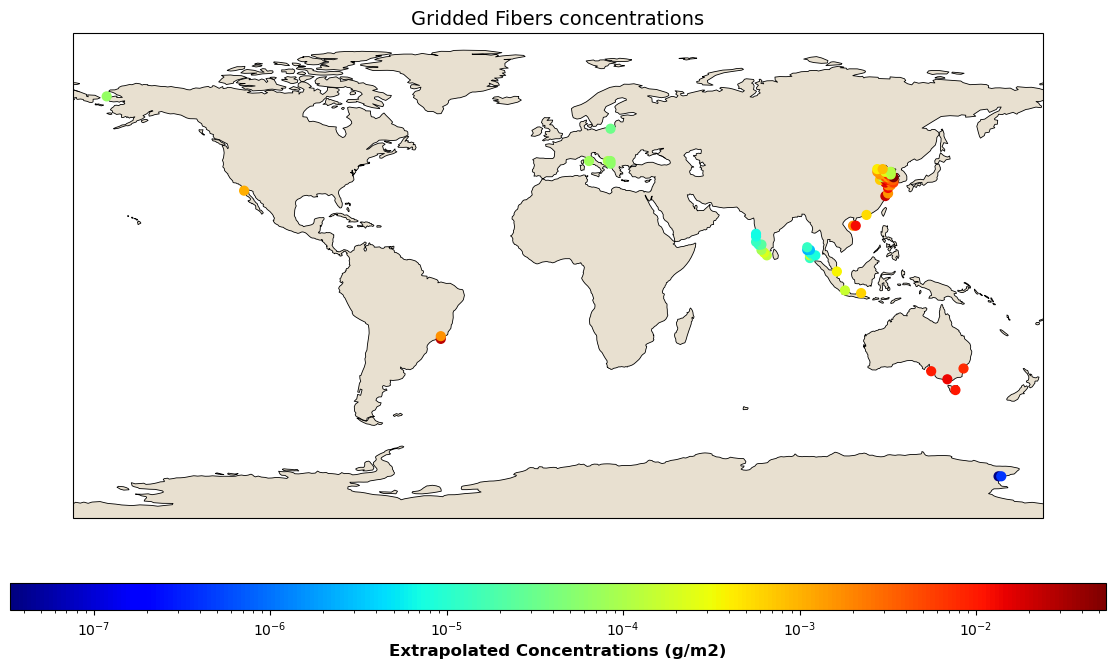

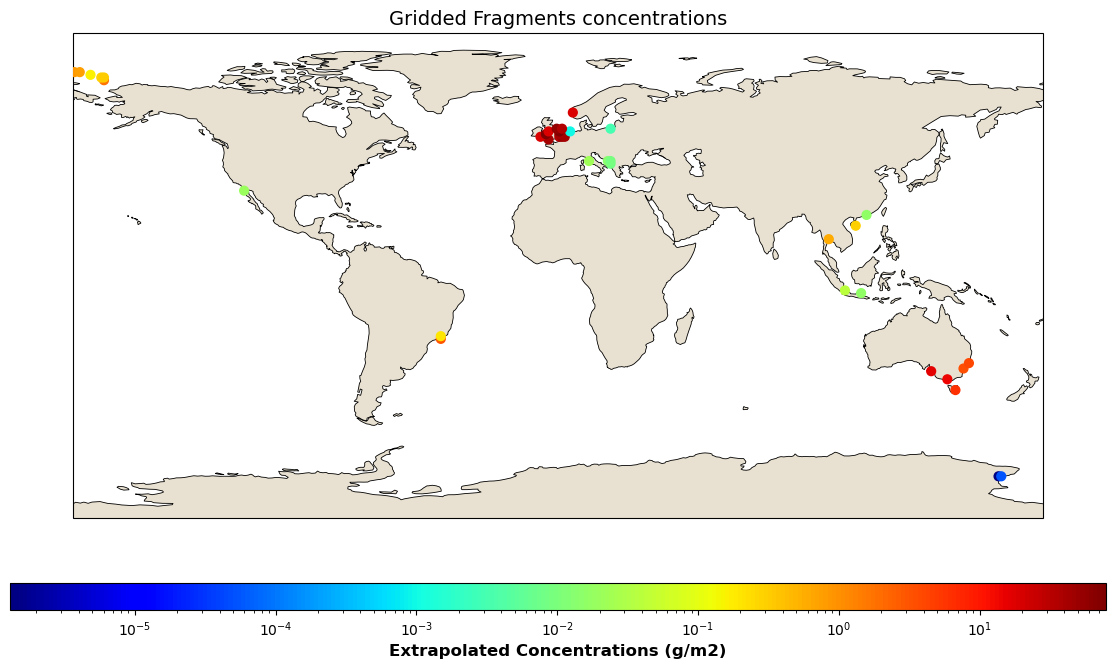

In [196]:
for shape in shapes:

    if shape == 'Fibers':
        data = gridded_data_fib
    else:
        data = gridded_data_frg

    vmin = min(data['MEAN MP stock (g/m2) in 2021'])
    vmax = max(data['MEAN MP stock (g/m2) in 2021'])
    norm = LogNorm(vmin=vmin, vmax=vmax)

    fig = plt.figure(figsize=(14, 7))

    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

    #ax.set_extent([115, 135, 29, 42], crs=ccrs.PlateCarree())

    scatter = ax.scatter(data['Lon_center'], data['Lat_center'],
                        c=data['MEAN MP stock (g/m2) in 2021'], 
                        s=40, 
                        cmap='jet',  # You can change this to 'plasma', 'hot', 'cool', etc.
                        norm=norm,  # Log scale for better visualization of wide range
                        zorder=5,
                        transform=ccrs.PlateCarree())
        
    """cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.1, shrink=0.8, aspect=40)"""

    """scatter2 = ax.scatter(all_data_fib['Lon'], all_data_fib['Lat'],
                        c=all_data_fib['MP stock (g/m2) in 2021'], 
                        s=40, 
                        cmap='viridis',  # You can change this to 'plasma', 'hot', 'cool', etc.
                        norm=norm,  # Log scale for better visualization of wide range
                        zorder=5,
                        marker = '^',
                        transform=ccrs.PlateCarree())"""
        
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.1, shrink=0.8, aspect=40)

    cbar.set_label('Extrapolated Concentrations (g/m2)', fontsize=12, fontweight='bold')

    plt.title(f"Gridded {shape} concentrations", fontsize=14)
    plt.tight_layout()
    plt.show()

## China seas

In [197]:
china_dataset = all_data_fib
all_data_fib['Lon'], all_data_fib['Lat']

china_dataset = all_data_fib[
    (all_data_fib['Lon'] >= 115) & (all_data_fib['Lon'] <= 130) &
    (all_data_fib['Lat'] >= 29)  & (all_data_fib['Lat'] <= 42)
].reset_index(drop=True)

In [198]:
np.max(china_dataset['Lon'])

np.float64(124.0)

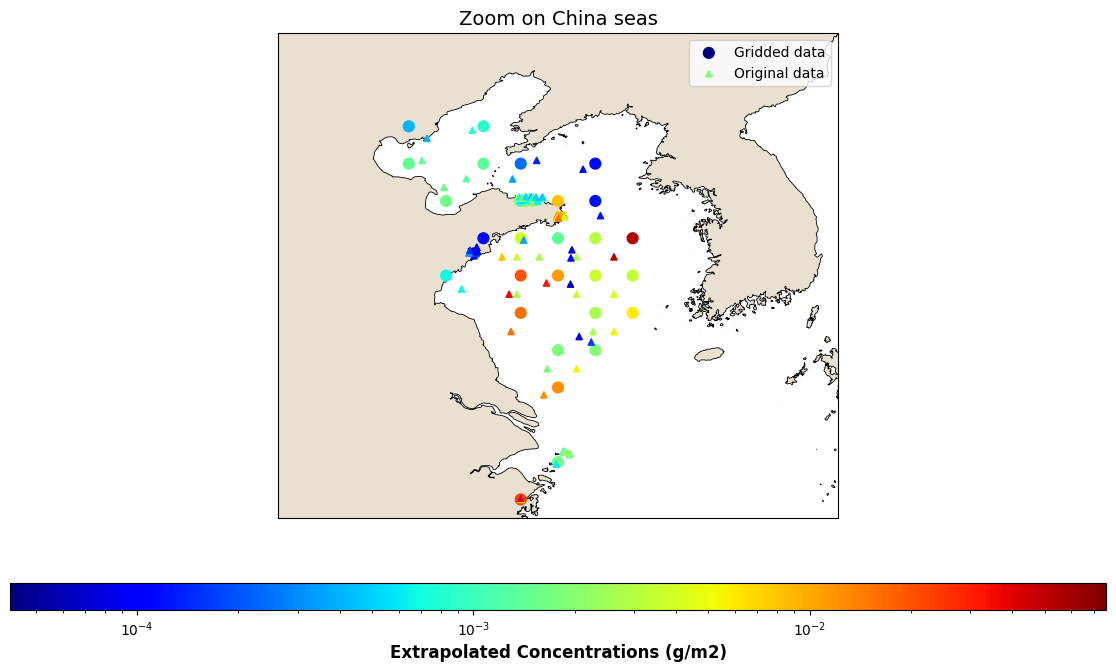

In [ ]:
original_conc = china_dataset['MP stock (g/m2) in 2021']
data = gridded_data_fib

vmin = min(original_conc)
vmax = max(original_conc)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(14, 7))

ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

ax.set_extent([115, 130, 29, 42], crs=ccrs.PlateCarree())

scatter = ax.scatter(data['Lon_center'], data['Lat_center'],
                        c=data['MEAN MP stock (g/m2) in 2021'], 
                        s=60, 
                        cmap='jet',  # You can change this to 'plasma', 'hot', 'cool', etc.
                        norm=norm,  # Log scale for better visualization of wide range
                        zorder=5,
                        label='Gridded data',
                        transform=ccrs.PlateCarree())
        

scatter2 = ax.scatter(china_dataset['Lon'], china_dataset['Lat'],
                        c=china_dataset['MP stock (g/m2) in 2021'], 
                        s=20, 
                        cmap='jet',  # You can change this to 'plasma', 'hot', 'cool', etc.
                        norm=norm,  # Log scale for better visualization of wide range
                        zorder=5,
                        marker = '^',
                        label='Original data',
                        transform=ccrs.PlateCarree())
        
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.1, shrink=0.8, aspect=40)

cbar.set_label('Extrapolated Concentrations (g/m2)', fontsize=12, fontweight='bold')

plt.title(f"Zoom on China seas", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

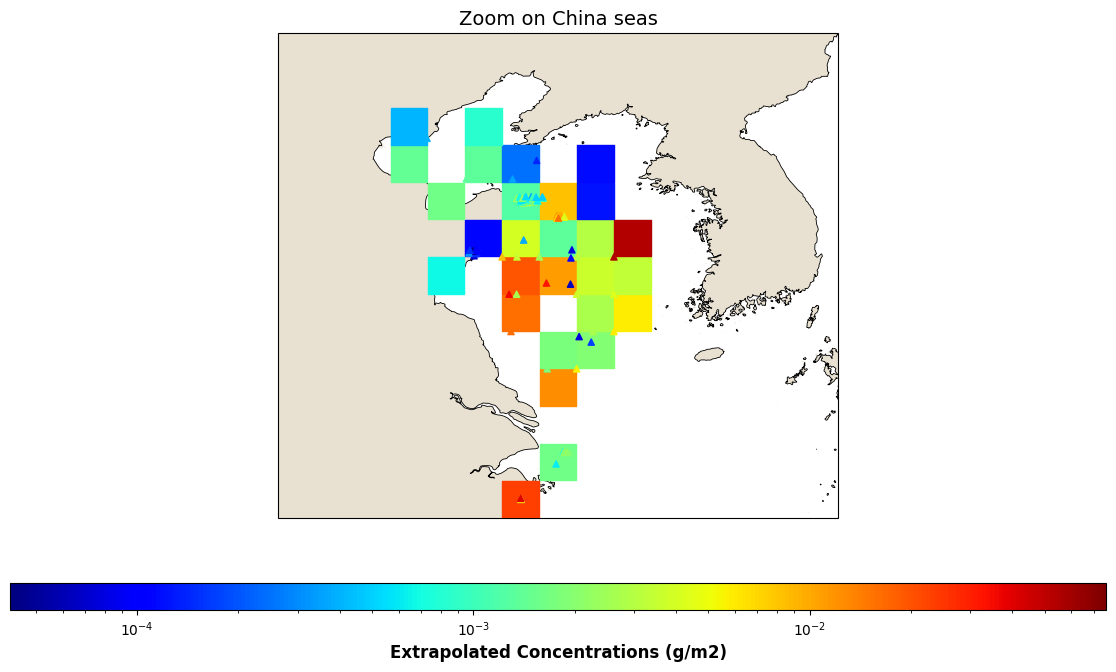

In [ ]:
cell_size = 1  # your grid resolution in degrees

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.set_extent([115, 130, 29, 42], crs=ccrs.PlateCarree())

mesh = ax.scatter(gridded_data_fib['Lon_center'], gridded_data_fib['Lat_center'],
                  c=gridded_data_fib['MEAN MP stock (g/m2) in 2021'],
                  cmap='jet', norm=norm,
                  marker='s',  # square marker
                  s=690,       # ADUJST HERE TO MAKE A GOOD SQUARES
                  zorder=4,
                  transform=ccrs.PlateCarree())

scatter2 = ax.scatter(china_dataset['Lon'], china_dataset['Lat'],
                      c=china_dataset['MP stock (g/m2) in 2021'],
                      s=20, cmap='jet', norm=norm,
                      marker='^', zorder=5,
                      transform=ccrs.PlateCarree())

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('Extrapolated Concentrations (g/m2)', fontsize=12, fontweight='bold')
plt.title("Zoom on China seas", fontsize=14)
plt.tight_layout()
plt.show()

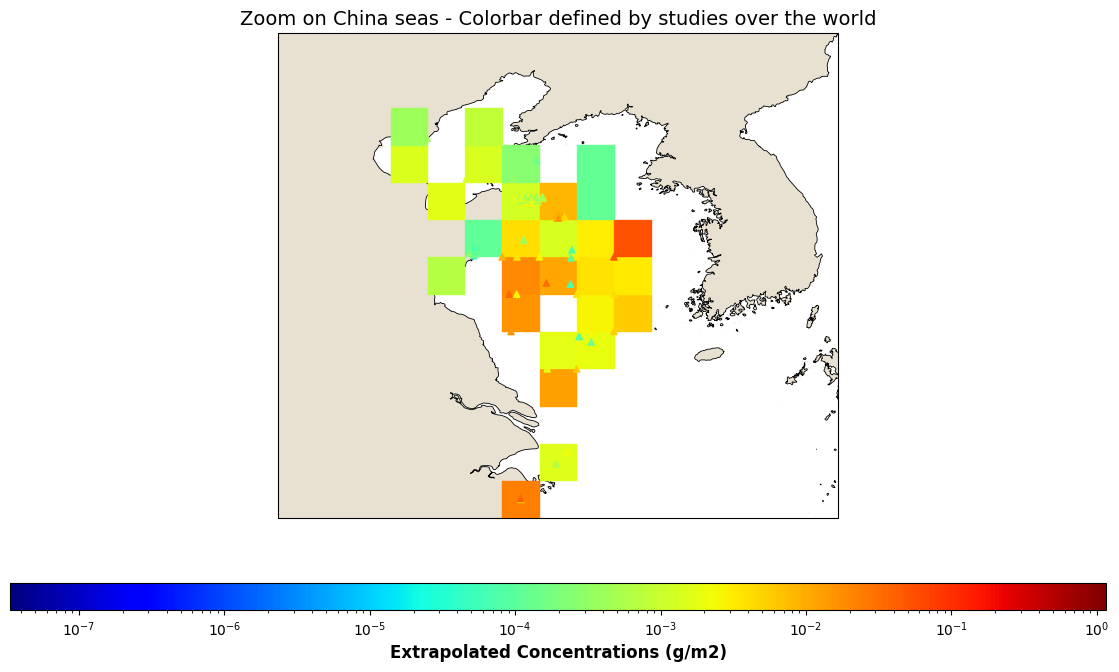

In [ ]:
vmin = min(gridded_data_fib['MEAN MP stock (g/m2) in 2021'])
vmax = max(gridded_data_fib['MEAN MP stock (g/m2) in 2021'])
norm = LogNorm(vmin=vmin, vmax=vmax)

cell_size = 1  # your grid resolution in degrees

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.set_extent([115, 130, 29, 42], crs=ccrs.PlateCarree())

mesh = ax.scatter(gridded_data_fib['Lon_center'], gridded_data_fib['Lat_center'],
                  c=gridded_data_fib['MEAN MP stock (g/m2) in 2021'],
                  cmap='jet', norm=norm,
                  marker='s',  # square marker
                  s=690,       # ADUJST HERE TO MAKE A GOOD SQUARES
                  zorder=4,
                  transform=ccrs.PlateCarree())

scatter2 = ax.scatter(china_dataset['Lon'], china_dataset['Lat'],
                      c=china_dataset['MP stock (g/m2) in 2021'],
                      s=20, cmap='jet', norm=norm,
                      marker='^', zorder=5,
                      transform=ccrs.PlateCarree())

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('Extrapolated Concentrations (g/m2)', fontsize=12, fontweight='bold')
plt.title("Zoom on China seas - Colorbar defined by studies over the world", fontsize=14)
plt.tight_layout()
plt.show()